# Confident Learning en Producción: Cleanlab Avanzado para Datos Tabulares

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/90_casos_estudio/confident_learning_avanzado.ipynb)

## Objetivos del Caso de Estudio


- **Desmitificar el *Ground Truth*:** Comprender que en la industria, las etiquetas humanas son inherentemente ruidosas y ambiguas (típicamente entre un 5% y un 15% de error).
- **Calibración de Probabilidades:** Aprender por qué los modelos modernos (como Random Forest) no están calibrados y cómo corregirlo usando *Platt Scaling* o Regresión Isotónica.
- **Consenso de Modelos (Ensembles):** Utilizar un `VotingClassifier` para generar probabilidades cruzadas (OOF) extremadamente robustas, evitando los sesgos de un algoritmo individual.
- **Intersección de Anomalías:** Cruzar los resultados de `cleanlab` con *Isolation Forest* para distinguir entre un cliente excéntrico (*Outlier*) y un error de tipeo humano (*Label Issue*).
- **Estrategias de Mitigación:** Evaluar qué hacer con las filas corruptas (Eliminar, Re-etiquetar o *Down-weighting*) y medir el ROI en producción.



## Prerrequisitos


- Entendimiento profundo de Validación Cruzada, Ensembles y Detección de Anomalías.
- Haber completado el Capítulo 3, especialmente: [Isolation Forest y LOF](../03_machine_learning/17_isolation_forest_y_lof.ipynb) y [Confident Learning](../03_machine_learning/19_confident_learning.ipynb).

---

## Configuración del Entorno


***Nota**: `cleanlab` suelen requerir instalación adicional, no está en Colab por defecto (al menos hasta ahora).*

***En la celda de abajo, se detecta automáticamente y se intenta instalar.***

**Nota2**: En entornos locales, este tipo de *frameworks* los recomiendo instalar en un entorno virtual dedicado, así no se "rompen" otras cosas. Suelen usar muchas dependencias con versiones muy concretas...

In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

    # Instalamos dependencias avanzadas
    subprocess.run(["pip", "install", "cleanlab", "xgboost"], check=True)
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
from utils.data import load_dataset
setup_plot_style()

## 1. Introducción: El Dogma del *Ground Truth*



En la academia, asumimos que la variable `y` (la etiqueta de salida) es la verdad absoluta. En la industria, `y` es simplemente "lo que un humano anotó un martes a las 4:45 PM después de tomar tres termos de mate, y con ganas de hacer otra cosa".

Si se entrena un modelo complejo sobre datos ruidosos, el modelo memorizará el ruido. La filosofía de **Data-Centric AI** y **Confident Learning** nos dice que, en lugar de pasar semanas ajustando hiperparámetros, debemos usar modelos simples para auditar y limpiar nuestros datos.

### El Contexto del Negocio: Bank Telemarketing



Trabajamos en un banco. Queremos predecir si un cliente aceptará un depósito a plazo fijo (`y = yes`).
Esta etiqueta es **propensa al error humano**. Los operadores del *Call Center* tienen cuotas que cumplir, sufren fatiga y a veces marcan "No" cuando el cliente dijo "Llamame mañana", o marcan "Sí" por error en el sistema.

Vamos a cargar los datos, realizar un preprocesamiento a prueba de fugas y, para simular la realidad, **inyectamos ruido dependiente de las características** (*Feature-Dependent Noise*).

## 2. Carga de Datos, EDA y Prevención de Leakage


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score
import cleanlab

# 1. Carga de datos reales
dataset_path = "datasets/bkm/bank-full.csv"
df_full = load_dataset(dataset_path)

# Tomamos una muestra de 15.000 clientes para agilizar el cómputo en este notebook
df = df_full.sample(n=15000, random_state=42).reset_index(drop=True)

# ⚠️ CRITERIO DE INGENIERÍA: Prevención de Data Leakage
# La variable 'duration' (duración de la llamada) ocurre DESPUÉS de que decidimos llamar al cliente.
# Si la incluimos, el modelo hará trampa (duración=0 significa que no contestó/no aceptó).
df = df.drop(columns=['duration'])

# Convertimos el target a binario
df['y'] = df['y'].map({'yes': 1, 'no': 0})

print(f"Total de registros: {len(df)}")
print(f"Tasa de conversión real (Ground Truth): {(df['y'].sum() / len(df)) * 100:.2f}%")

Archivo CSV no encontrado. Descomprimiendo /content/applied-ai-engineering/datasets/bkm/bank-full.zip...
Descompresión completa. Intentando cargar el CSV.
Dataset cargado exitosamente con 45211 filas y 17 columnas.
Total de registros: 15000
Tasa de conversión real (Ground Truth): 11.71%


### Inyección de Ruido Realista (Feature-Dependent Noise)


En la vida real, los humanos no se equivocan al azar. Se equivocan en los casos de alta fricción.
Vamos a corromper las etiquetas de los clientes que tienen **saldo negativo (`balance < 0`) y préstamos activos (`loan == 'yes'`)**. Estas llamadas suelen ser tensas, el cliente quiere colgar rápido, y el operador es más propenso a registrar mal el resultado.

In [5]:
# Guardamos el Ground Truth intacto (El modelo NUNCA lo verá)
y_limpio = df['y'].values
y_ruidoso = np.copy(y_limpio)

# Definimos el perfil de "Alta Fricción"
casos_dificiles = (df['balance'] < 0) | (df['loan'] == 'yes') | (df['campaign'] > 5)
indices_dificiles = df[casos_dificiles].index

# Volteamos el 25% de las etiquetas SOLO en estos perfiles difíciles
np.random.seed(42)
ruido_idx = np.random.choice(indices_dificiles, size=int(0.25 * len(indices_dificiles)), replace=False)
y_ruidoso[ruido_idx] = 1 - y_ruidoso[ruido_idx]

print(f"Errores humanos inyectados: {len(ruido_idx)} ({(len(ruido_idx)/len(df))*100:.2f}% del dataset total)")

# Reemplazamos la columna en el DataFrame para el entrenamiento
df['y_noisy'] = y_ruidoso
X = df.drop(columns=['y', 'y_noisy'])

# División Train/Test
X_train, X_test, y_train_ruidoso, y_test_limpio = train_test_split(X, df['y_noisy'], test_size=0.2, random_state=42, stratify=df['y_noisy'])
_, _, y_train_limpio, _ = train_test_split(X, df['y'], test_size=0.2, random_state=42, stratify=df['y_noisy'])

# Preprocesamiento "robusto"...
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocesador = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
])

X_train_proc = preprocesador.fit_transform(X_train)
X_test_proc = preprocesador.transform(X_test)

Errores humanos inyectados: 1096 (7.31% del dataset total)


## 3. El Talón de Aquiles: La Calibración de Probabilidades


`cleanlab` funciona comparando la etiqueta humana con la probabilidad que emite el modelo. Si el modelo dice "Estoy 95% seguro de que esto es un fraude", `cleanlab` le cree y marca la etiqueta humana como errónea.

**⚠️ El Peligro:**  
Los modelos basados en árboles (Random Forest, XGBoost) **no están calibrados**. Un Random Forest rara vez emite una probabilidad de `0.99` o `0.01`; sus probabilidades tienden a agruparse en el centro (0.2 a 0.8) porque son promedios de cientos de árboles. Si le pasamos probabilidades sin calibrar a `cleanlab`, no encontrará los errores correctamente.

Vamos a visualizar esto usando una **Curva de Confiabilidad** (*Reliability Diagram*).

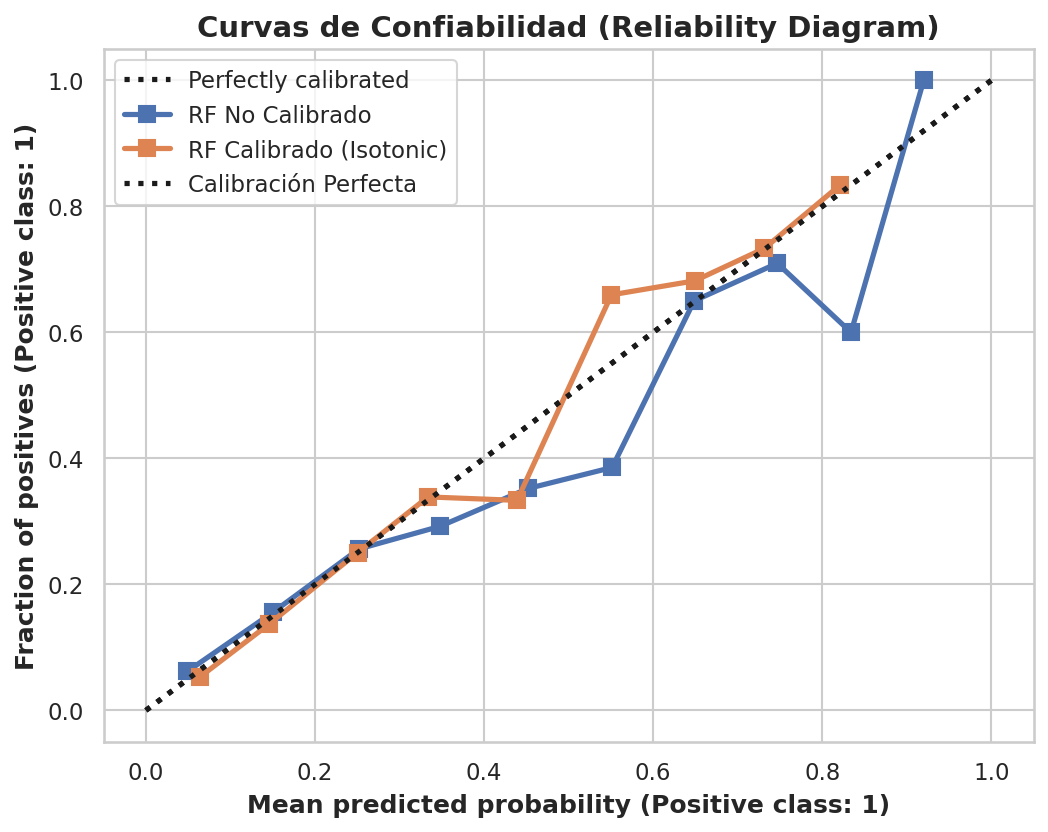

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV

# Entrenamos un Random Forest estándar
rf_no_calibrado = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_no_calibrado.fit(X_train_proc, y_train_ruidoso)

# Entrenamos un Random Forest CALIBRADO (Usando Regresión Isotónica o Platt Scaling)
# cv=5 asegura que la calibración se haga sin Data Leakage
rf_calibrado = CalibratedClassifierCV(estimator=rf_no_calibrado, method='isotonic', cv=5)
rf_calibrado.fit(X_train_proc, y_train_ruidoso)

# Visualizamos la calibración
fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_estimator(rf_no_calibrado, X_test_proc, y_test_limpio, n_bins=10, ax=ax, name='RF No Calibrado')
CalibrationDisplay.from_estimator(rf_calibrado, X_test_proc, y_test_limpio, n_bins=10, ax=ax, name='RF Calibrado (Isotonic)')
ax.plot([0, 1], [0, 1], "k:", label="Calibración Perfecta")
plt.title("Curvas de Confiabilidad (Reliability Diagram)")
plt.legend()
plt.show()

*Criterio de Ingeniería:* Observar cómo la curva del modelo calibrado (naranja) se ajusta mucho mejor a la línea punteada diagonal (la perfección matemática). Ahora, cuando el modelo diga "90% de probabilidad", realmente acertará el 90% de las veces.

## 4. Consenso de Modelos (Ensembles)

Si usamos un solo algoritmo (ej. Regresión Logística) para generar las probabilidades, `cleanlab` heredará los sesgos lineales de ese algoritmo. Si usamos solo Random Forest, heredamos sus sesgos espaciales.

Para obtener las probabilidades *Out-of-Fold* (OOF) más robustas posibles, creamos una "Junta de Expertos" (`VotingClassifier`) compuesta por algoritmos de diferentes familias:
1. **Regresión Logística:** Aporta la visión lineal y probabilística pura (naturalmente bien calibrada).
2. **Random Forest (Calibrado):** Aporta la visión no lineal de baja varianza (*Bagging*).
3. **HistGradientBoosting:** Aporta la visión de corrección de errores secuenciales (*Boosting*).


> **NOTA**: no existe realmente un "oráculo" con todas las respuestas correctas *siempre*. El entendimiento del contexto, las limitaciones y naturaleza del problema, etc. etc... **siempre** aporta a encontrar el "camino correcto".

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, VotingClassifier

# 1. Definimos los miembros de la junta de expertos
clf1 = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
clf2 = CalibratedClassifierCV(RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42), method='isotonic', cv=3)
clf3 = HistGradientBoostingClassifier(random_state=42)

# 2. Creamos el Ensemble con 'soft' voting (promedia las probabilidades, no las clases duras)
ensemble_voting = VotingClassifier(
    estimators=[('lr', clf1), ('rf', clf2), ('hgb', clf3)],
    voting='soft'
)

# 3. Generamos las Probabilidades OOF (Out-of-Fold)
# Usamos StratifiedKFold para mantener la proporción de clases en cada fold
print("Generando probabilidades OOF con el Ensemble (Esto puede tardar un poco)...")
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

probabilidades_oof = cross_val_predict(
    estimator=ensemble_voting,
    X=X_train_proc,
    y=y_train_ruidoso,
    cv=cv_strategy,
    method='predict_proba',
    n_jobs=-1
)
print("Probabilidades OOF generadas con éxito.")

Generando probabilidades OOF con el Ensemble (Esto puede tardar un poco)...
Probabilidades OOF generadas con éxito.


## 5. Confident Learning: La Auditoría con Cleanlab


Ahora tenemos los ingredientes: etiquetas humanas (ruidosas) y probabilidades de máquina (robustas, consensuadas y calibradas). Pasamos esto por el motor de `cleanlab`:

In [12]:
# Encontramos los errores de etiqueta
etiquetas_con_problemas = cleanlab.filter.find_label_issues(
    labels=y_train_ruidoso.values,
    pred_probs=probabilidades_oof,
    filter_by='prune_by_noise_rate', # Estrategia matemática robusta para estimar la matriz de ruido
    return_indices_ranked_by='self_confidence' # Ordena del error más grave al más dudoso
)

print(f"Cleanlab detectó {len(etiquetas_con_problemas)} posibles errores de etiquetado.")

# Verificamos contra nuestro Ground Truth oculto (Solo posible en este laboratorio)
errores_reales_encontrados = sum(y_train_ruidoso.values[etiquetas_con_problemas] != y_train_limpio.values[etiquetas_con_problemas])
precision_cleanlab = errores_reales_encontrados / len(etiquetas_con_problemas)

print(f"De los detectados, {errores_reales_encontrados} eran errores reales que inyectamos.")
print(f"Precisión de la auditoría: {precision_cleanlab*100:.2f}%")

Cleanlab detectó 1056 posibles errores de etiquetado.
De los detectados, 207 eran errores reales que inyectamos.
Precisión de la auditoría: 19.60%


## 6. Outliers vs. Errores de Etiqueta (El Falso Positivo de Cleanlab)


Aquí es donde un Ingeniero *Senior* demuestra su valor.

Supongamos que `cleanlab` marcó al Cliente #842 como un error. ¿Es realmente un error del operador del *Call Center*? ¿O es que el Cliente #842 es un multimillonario de 90 años, estudiante, con 5 préstamos (un perfil rarísimo) y su comportamiento es tan extraño que el modelo se confundió?

Matemáticamente: `cleanlab` evalúa $P(y|x)$ (la probabilidad de la etiqueta dado el cliente). Pero si $P(x)$ (la probabilidad de que ese cliente exista) es casi cero porque es un *Outlier*, ¡la estimación del modelo no es confiable!

Para evitar borrar *Outliers* valiosos, damos un paso más. Cruzamos la lista de `cleanlab` con los *Scores* de **Isolation Forest**.

In [13]:
from sklearn.ensemble import IsolationForest

# 1. Calculamos el nivel de "excentricidad" espacial de cada cliente
iforest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42, n_jobs=-1)
outlier_preds = iforest.fit_predict(X_train_proc) # -1 es Outlier, 1 es Normal

# 2. Intersección de Lógica
indices_cleanlab_set = set(etiquetas_con_problemas)
indices_outliers_set = set(np.where(outlier_preds == -1)[0])

# Clientes que Cleanlab dice que están mal etiquetados, PERO que también son Outliers espaciales
casos_complejos = indices_cleanlab_set.intersection(indices_outliers_set)

# Clientes que Cleanlab dice que están mal etiquetados, y que son clientes totalmente normales (Alta densidad)
errores_puros = indices_cleanlab_set - indices_outliers_set

print(f"Errores Puros (Probable error humano, seguros de corregir): {len(errores_puros)}")
print(f"Casos Complejos (Outliers + Label Issue, requieren revisión manual experta): {len(casos_complejos)}")

Errores Puros (Probable error humano, seguros de corregir): 952
Casos Complejos (Outliers + Label Issue, requieren revisión manual experta): 104


**Criterio de Acción en Producción:**
- Los **Errores Puros** pueden ser eliminados o re-etiquetados automáticamente.
- Los **Casos Complejos** son los "Cisnes Negros". No deben ser borrados automáticamente. Deben ser enviados a un analista de negocio experto para que los revise uno a uno.

## 7. Estrategias de Mitigación y ROI de Negocio


¿Qué hacemos con los errores que encontramos? Tenemos tres opciones:
1. **Re-etiquetar (Peligroso):** Cambiar la etiqueta humana por la del modelo. Riesgo de sesgo de confirmación.
2. **Down-weighting (Avanzado):** Mantener la fila, pero decirle al modelo final que le dé un "peso" (`sample_weight`) cercano a 0 durante el entrenamiento.
3. **Eliminar (Estándar de la Industria):** Simplemente borrar las filas corruptas. Es seguro y efectivo si se tienen suficientes datos.

Vamos a aplicar la estrategia de **Eliminar** (solo los Errores Puros) y medimos el impacto en el modelo final.

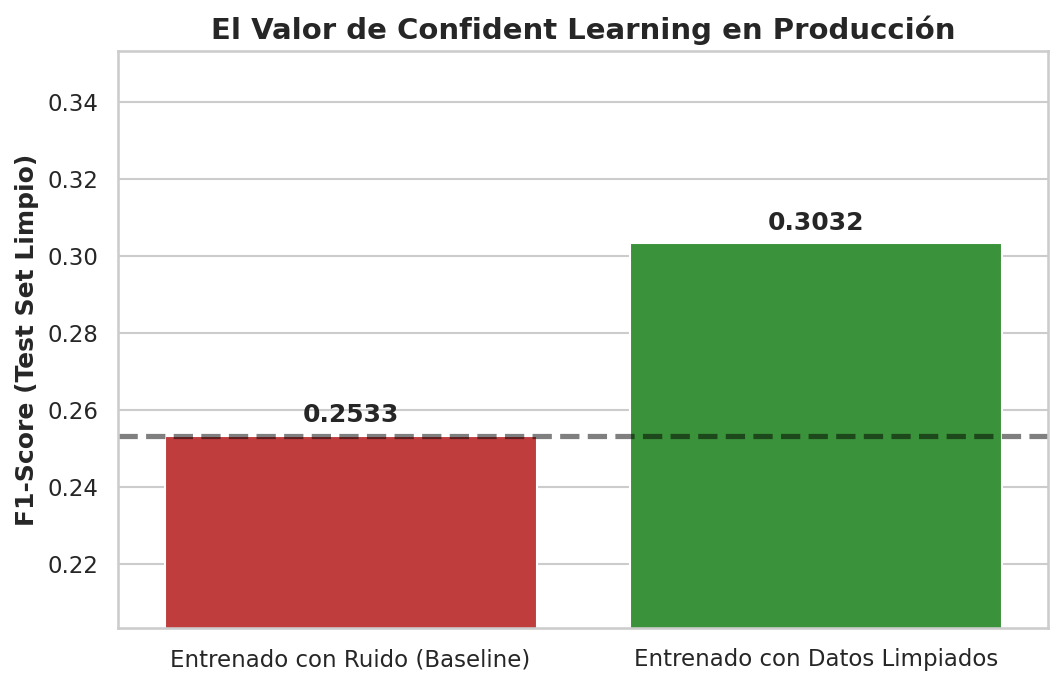

In [15]:
# 1. Creamos el dataset limpio (Eliminando SOLO los Errores Puros detectados)
X_train_limpiado = np.delete(X_train_proc, list(errores_puros), axis=0)
y_train_limpiado = np.delete(y_train_ruidoso.values, list(errores_puros), axis=0)

# 2. Entrenamos el modelo final (XGBoost/HistGradientBoosting) sobre los datos RUIDOSOS (Baseline)
modelo_final_ruidoso = HistGradientBoostingClassifier(random_state=42)
modelo_final_ruidoso.fit(X_train_proc, y_train_ruidoso)
f1_ruidoso = f1_score(y_test_limpio, modelo_final_ruidoso.predict(X_test_proc))

# 3. Entrenamos el MISMO modelo sobre los datos LIMPIADOS
modelo_final_limpio = HistGradientBoostingClassifier(random_state=42)
modelo_final_limpio.fit(X_train_limpiado, y_train_limpiado)
f1_limpio = f1_score(y_test_limpio, modelo_final_limpio.predict(X_test_proc))

# Visualización del ROI
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=['Entrenado con Ruido (Baseline)', 'Entrenado con Datos Limpiados'],
                 y=[f1_ruidoso, f1_limpio], palette=['#d62728', '#2ca02c'])

# Añadimos los valores sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

plt.axhline(y=f1_ruidoso, color='black', linestyle='--', alpha=0.5)
plt.title("El Valor de Confident Learning en Producción", fontsize=14)
plt.ylabel("F1-Score (Test Set Limpio)")
plt.ylim(min(f1_ruidoso, f1_limpio) - 0.05, max(f1_ruidoso, f1_limpio) + 0.05)
plt.show()

### Conclusión de Arquitectura MLOps


Observar el salto en el *F1-Score*. Mejoramos el rendimiento del modelo en producción **sin cambiar una sola línea de código del algoritmo predictivo**, simplemente mejorando la calidad del combustible (los datos) que lo alimenta.

Esta es casi "La Biblia de Cleanlab" para datos tabulares:
1. Nunca confiar ciegamente en las etiquetas humanas.
2. Calibrar siempre las probabilidades antes de auditar.
3. Usar un *Ensemble* para evitar los sesgos de un solo algoritmo.
4. Cruzar los errores de etiqueta con Detección de Anomalías Espacial (*Isolation Forest*) para no borrar *Outliers* valiosos.
5. Eliminar o revisar manualmente el ruido.


> Con este flujo de trabajo, nuestros modelos se construyen sobre cimientos de roca, no sobre arena. (*algo de esto aparece en la Biblia posta también...*)

## Referencias


1. Northcutt, C. G., Jiang, L., & Chuang, I. L. (2021). *Confident learning: Estimating uncertainty in dataset labels*. Journal of Artificial Intelligence Research (JAIR), 70, 1373-1411.
2. [Documentación Oficial de Cleanlab](https://docs.cleanlab.ai/stable/index.html)
3. [Scikit-Learn: Probability Calibration](https://scikit-learn.org/stable/modules/calibration.html)

---

## Entorno de Ejecución


In [17]:
from utils.environment import environment_table
environment_table(include_all=True)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
Cython,3.0.12
IPython,7.34.0
PIL,11.3.0
aiohappyeyeballs,2.6.1
aiohttp,3.13.5
aiosignal,1.4.0
anyio,4.13.0
anywidget,0.9.21
